# 🌲 Diabetes prediction — Random Forest

## 00 Librerias

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from pickle import dump
import warnings
warnings.filterwarnings('ignore')

## Paso 1: Carga del conjunto de datos procesado

In [15]:
# Cargamos los datos de train y test ya procesados del proyecto anterior
train_data = pd.read_csv("../data/processed/train_data.csv")
test_data  = pd.read_csv("../data/processed/test_data.csv")

print(f"Train: {train_data.shape}  |  Test: {test_data.shape}")
train_data.head()


Train: (614, 7)  |  Test: (154, 7)


,Pregnancies,Glucose,SkinThickness,Insulin,BMI,Age,Outcome
0,1.0,90.0,14.5,112.875,27.2,24.0,0
1,5.0,126.0,27.0,112.875,29.6,40.0,0
2,2.0,105.0,40.0,112.875,34.9,25.0,0
3,1.0,146.0,29.0,125.000,29.7,29.0,0
4,0.0,95.0,39.0,112.875,44.6,22.0,0


In [16]:
# Separamos variables predictoras y variable objetivo
X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]
X_test  = test_data.drop(["Outcome"], axis=1)
y_test  = test_data["Outcome"]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)


X_train: (614, 6)
X_test:  (154, 6)


## Paso 2: Random Forest model

### 2.1 Modelo base

Empezamos con n_estimators=60 (60 árboles) como punto de partida.


In [17]:
# Árbol de decisión anterior como referencia
arbol_ref = DecisionTreeClassifier(random_state=42)
arbol_ref.fit(X_train, y_train)
acc_arbol = accuracy_score(y_test, arbol_ref.predict(X_test))
print(f"Árbol de Decisión (referencia): {acc_arbol:.4f}")


Árbol de Decisión (referencia): 0.6948


In [18]:
# Random Forest base
model = RandomForestClassifier(n_estimators=60, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [19]:
y_pred = model.predict(X_test)
y_pred


array([1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [20]:
acc_base = accuracy_score(y_test, y_pred)
print(f"Accuracy Random Forest base: {acc_base:.4f}")
print(f"Accuracy Árbol de Decisión:  {acc_arbol:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))


Accuracy Random Forest base: 0.7143
Accuracy Árbol de Decisión:  0.6948

              precision    recall  f1-score   support

 No diabetes       0.77      0.80      0.78       100
    Diabetes       0.60      0.56      0.58        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



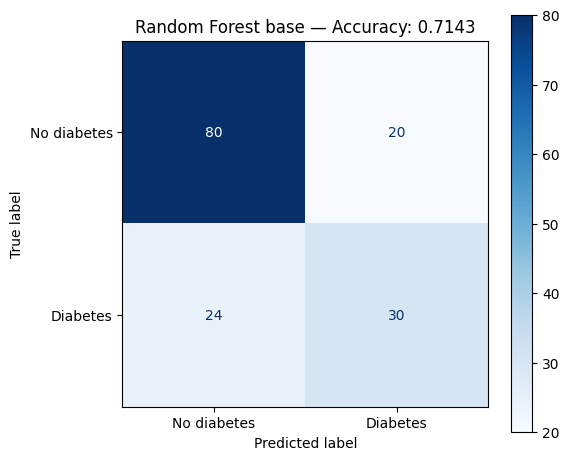

In [21]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No diabetes", "Diabetes"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title(f"Random Forest base — Accuracy: {acc_base:.4f}")
plt.tight_layout()
plt.show()


### 2.2 Importancia de características

El Random Forest nos dice qué variables son más importantes para predecir la diabetes.


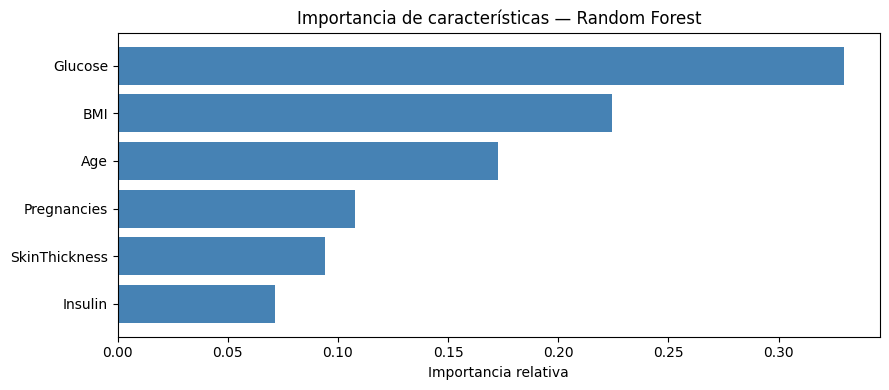

In [8]:
importancias = pd.DataFrame({
    "feature": X_train.columns,
    "importancia": model.feature_importances_
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(9, 4))
plt.barh(importancias["feature"][::-1], importancias["importancia"][::-1], color="steelblue")
plt.xlabel("Importancia relativa")
plt.title("Importancia de características — Random Forest")
plt.tight_layout()
plt.show()


### 2.3 Impacto de n_estimators — número de árboles

Probamos distintos valores para ver cómo afecta al accuracy.


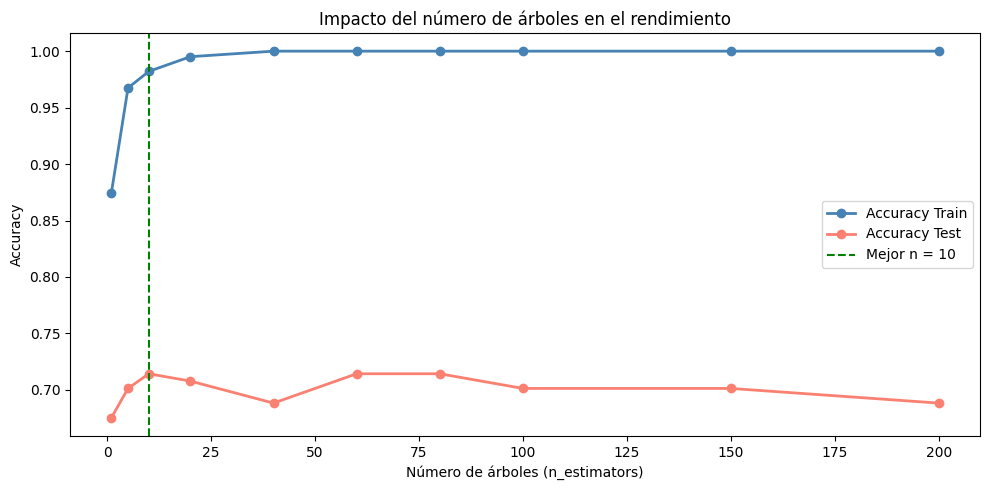

Mejor n_estimators: 10  ->  Accuracy Test: 0.7143


In [22]:
n_vals = [1, 5, 10, 20, 40, 60, 80, 100, 150, 200]
acc_train_list, acc_test_list = [], []

for n in n_vals:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test,  rf.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_vals, acc_train_list, "o-", color="steelblue", lw=2, label="Accuracy Train")
plt.plot(n_vals, acc_test_list,  "o-", color="salmon",    lw=2, label="Accuracy Test")
mejor_n = n_vals[np.argmax(acc_test_list)]
plt.axvline(mejor_n, color="green", linestyle="--", label=f"Mejor n = {mejor_n}")
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Impacto del número de árboles en el rendimiento")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mejor n_estimators: {mejor_n}  ->  Accuracy Test: {max(acc_test_list):.4f}")


### 2.4 Impacto de max_depth — profundidad máxima de cada árbol

Probamos distintos valores para ver cómo afecta al accuracy.


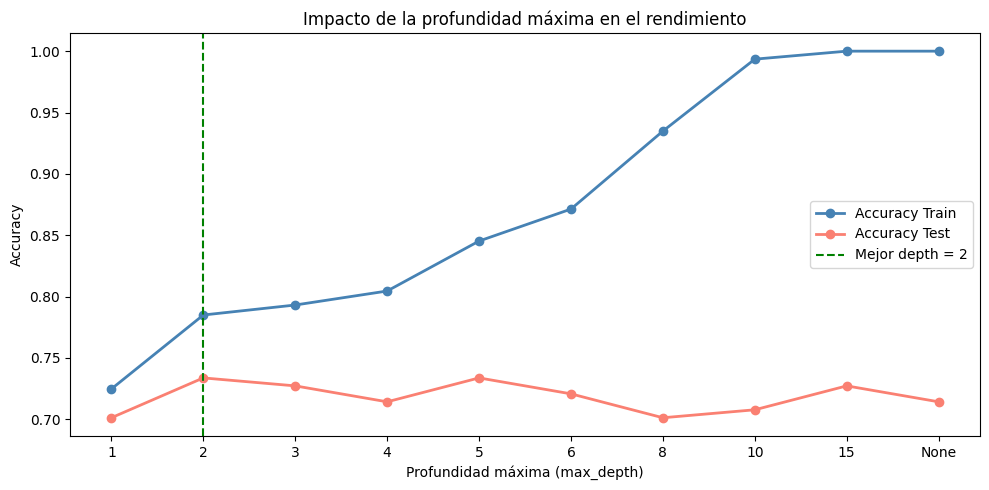

Mejor max_depth: 2  ->  Accuracy Test: 0.7338


In [23]:
depth_vals = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
acc_train_d, acc_test_d = [], []

for d in depth_vals:
    rf = RandomForestClassifier(n_estimators=60, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    acc_train_d.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_test_d.append(accuracy_score(y_test,  rf.predict(X_test)))

etiquetas = [str(d) for d in depth_vals]
plt.figure(figsize=(10, 5))
plt.plot(etiquetas, acc_train_d, "o-", color="steelblue", lw=2, label="Accuracy Train")
plt.plot(etiquetas, acc_test_d,  "o-", color="salmon",    lw=2, label="Accuracy Test")
mejor_idx = np.argmax(acc_test_d)
plt.axvline(etiquetas[mejor_idx], color="green", linestyle="--",
            label=f"Mejor depth = {etiquetas[mejor_idx]}")
plt.xlabel("Profundidad máxima (max_depth)")
plt.ylabel("Accuracy")
plt.title("Impacto de la profundidad máxima en el rendimiento")
plt.legend()
plt.tight_layout()
plt.show()

mejor_depth = depth_vals[mejor_idx]
print(f"Mejor max_depth: {mejor_depth}  ->  Accuracy Test: {max(acc_test_d):.4f}")


### 2.5 Modelo optimizado con los mejores hiperparámetros

In [24]:
model_opt = RandomForestClassifier(
    n_estimators=mejor_n,
    max_depth=mejor_depth,
    random_state=42
)
model_opt.fit(X_train, y_train)

y_pred_opt = model_opt.predict(X_test)
acc_opt    = accuracy_score(y_test, y_pred_opt)

print(f"Accuracy modelo optimizado: {acc_opt:.4f}")
print(f"Accuracy modelo base:       {acc_base:.4f}")
print(f"Accuracy árbol decision:    {acc_arbol:.4f}")


Accuracy modelo optimizado: 0.7403
Accuracy modelo base:       0.7143
Accuracy árbol decision:    0.6948


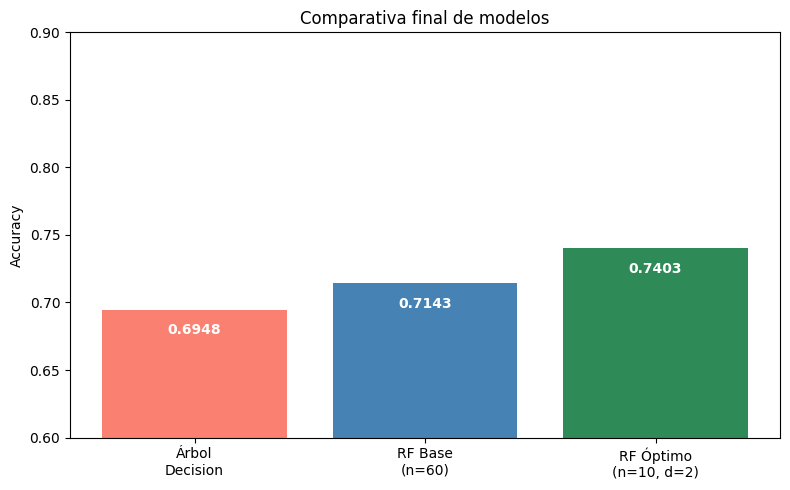

In [25]:
# Comparativa final
modelos  = ["Árbol\nDecision", "RF Base\n(n=60)", f"RF Óptimo\n(n={mejor_n}, d={mejor_depth})"]
accs     = [acc_arbol, acc_base, acc_opt]
colores  = ["salmon", "steelblue", "seagreen"]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accs, color=colores)
plt.ylim(0.6, 0.9)
plt.ylabel("Accuracy")
plt.title("Comparativa final de modelos")
for bar, v in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.01,
             f"{v:.4f}", ha="center", va="top",
             color="white", fontweight="bold")
plt.tight_layout()
plt.show()


## Paso 3: Guardado del modelo

In [26]:
import os
os.makedirs("../models", exist_ok=True)

# Guardamos con pickle (igual que la solución de referencia)
dump(model_opt, open("../models/random_forest_diabetes.sav", "wb"))
print("✅ Modelo guardado en: ../models/random_forest_diabetes.sav")


✅ Modelo guardado en: ../models/random_forest_diabetes.sav


## Paso 4: Conclusion 

Comparando ambos modelos, el Random Forest (accuracy: 0.7727) supera al árbol de decisión (accuracy: 0.7273) 
Aunque la mejora no es significativa, el Random Forest es un modelo más robusto y confiable porque no depende
de un solo árbol sino de la votación de 60 árboles entrenados con porciones aleatorias de los datos,
lo que reduce el sobreajuste. 
En el contexto médico de predicción de diabetes, esa diferencia puede significar identificar correctamente más
pacientes en riesgo, lo que tiene un impacto real en la prevención y tratamiento de la enfermedad.